<h3 style="color:#6FA8DC; font-weight:bold">01. Binning / Discretization & Binarization</h3>

<h5 style="color:#78B89A; font-weight:bold;">Big picture</h5>

**Binning / Discretization** converts a continuous numerical feature into a small number of groups (bins).

**Binarization** converts numerical values into **0 or 1** based on a threshold.

```text
CONTINUOUS FEATURE
        ↓
 ┌──────┴─────────┐
 ↓                ↓
Discretization   Binarization
 ↓                ↓
many bins        0 / 1
```

Example:

```text
Age = 23, 31, 47, 68
       ↓
Age bins
       ↓
Young / Adult / Senior
```

or:

```text
Age > 18
   ↓
  1
Age ≤ 18
   ↓
  0
```

<h5 style="color:#78B89A; font-weight:bold;">1. Encoding Numerical Features</h5>

Most ML models can directly work with numerical values, but sometimes the **way numerical values are represented** is not ideal.

For example:

```text
Age:
5, 8, 17, 25, 42, 65, 80
```

We can represent Age as groups:

```text
0 → child
1 → young
2 → adult
3 → senior
```

This process is called **discretization / binning**.

Important:

> Discretization is not required for every numerical feature. It is a feature-engineering choice that should be evaluated with the model.

<h5 style="color:#78B89A; font-weight:bold;">2. Discretization</h5>

**Discretization = converting a continuous numerical variable into discrete intervals (bins).**

Example:

```text
Age
 ↓
0–18     → Bin 0
19–35    → Bin 1
36–55    → Bin 2
56+      → Bin 3
```

Instead of giving the model the exact value `42`, we can give it the bin representing the age range.

### Why use it?

- reduce the effect of small fluctuations
- capture non-linear/range-based relationships
- make a continuous feature easier to interpret
- sometimes improve a model's performance

### Important

Binning loses information.

```text
Age 21
Age 34
```

may become the same bin even though their exact values are different.

So always compare model performance before and after binning.

<h5 style="color:#78B89A; font-weight:bold;">3. Types of Discretization</h5>

The main approaches covered here are:

```text
Discretization
│
├── Equal Width / Uniform Binning
│
├── Equal Frequency / Quantile Binning
│
├── KMeans Binning
│
└── Custom / Domain-Based Binning
```

Scikit-learn provides these strategies through:

```python
KBinsDiscretizer()
```



<h5 style="color:#78B89A; font-weight:bold;">4. Equal Width / Uniform Binning</h5>

The complete numerical range is divided into bins having approximately the **same width**.

Example:

```text
Age range = 0 → 80
Number of bins = 4

0–20
20–40
40–60
60–80
```

The intervals have similar numerical width.

```python
KBinsDiscretizer(
    n_bins=4,
    strategy="uniform",
    encode="ordinal"
)
```

### Best mental model

```text
MIN ───|────|────|────|─── MAX
       equal-width intervals
```

It can work well when the numerical range itself is meaningful, but if the data is heavily skewed, some bins may contain very few observations.

<h5 style="color:#78B89A; font-weight:bold;">5. Equal Frequency / Quantile Binning</h5>

Quantile binning tries to put approximately the **same number of observations** into each bin.

Example:

```text
Data sorted
 ↓
split according to quantiles
 ↓
Bin 0 → roughly same number of rows
Bin 1 → roughly same number of rows
Bin 2 → roughly same number of rows
Bin 3 → roughly same number of rows
```

Scikit-learn:

```python
KBinsDiscretizer(
    n_bins=4,
    strategy="quantile",
    encode="ordinal"
)
```

### Mental model

```text
DATA → sort → divide by quantiles
```

This can be useful for skewed distributions because the bins are based on the **data distribution**, rather than equal numerical ranges.

Your Day 32 notebook uses this strategy for the Titanic `Age` and `Fare` features.

<h5 style="color:#78B89A; font-weight:bold;">6. KMeans Binning</h5>

KMeans binning uses **K-Means clustering** to find groups in a numerical feature.

```text
Numerical values
      ↓
K-Means
      ↓
clusters
      ↓
bins
```

In Scikit-learn:

```python
KBinsDiscretizer(
    n_bins=5,
    strategy="kmeans",
    encode="ordinal"
)
```

The boundaries are influenced by where the data naturally forms clusters.

### Difference

```text
Uniform
→ equal numerical width

Quantile
→ roughly equal number of samples

KMeans
→ bins based on clusters in the data
```

KMeans binning can be useful when the data has natural groupings.

<h5 style="color:#78B89A; font-weight:bold;">7. Encoding the Discretized Variable</h5>

After creating bins, we need to decide how those bins are represented.

With:

```python
encode="ordinal"
```

we get:

```text
Bin 0 → 0
Bin 1 → 1
Bin 2 → 2
Bin 3 → 3
```

Another option is:

```python
encode="onehot"
```

which represents each bin as a separate indicator feature.

For a Pipeline-friendly sparse representation, newer Scikit-learn versions also support:

```python
encode="onehot-dense"
```

### Important

Ordinal bin numbers are **labels for intervals**. Do not automatically interpret them as a meaningful linear distance.

```text
Bin 0 → Bin 1
```

does not necessarily mean the underlying values are equally spaced in their original units.

<h5 style="color:#78B89A; font-weight:bold;">8. Practical Example — Titanic</h5>

Your provided Day 32 notebook uses:

```text
Age
Fare
Survived
```

The practical workflow is:

```text
Titanic data
   ↓
Remove missing values
   ↓
X = Age + Fare
y = Survived
   ↓
Train/Test Split
   ↓
Decision Tree
   ↓
Baseline accuracy
   ↓
Apply KBinsDiscretizer
   ↓
Train Decision Tree again
   ↓
Compare accuracy
```

The source notebook uses **quantile binning** with 15 bins and ordinal encoding.

The complete source-based practical code is included below.

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [4]:
df.dropna(inplace=True)

In [5]:
df.shape

(714, 3)

In [6]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [7]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [8]:

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
X_train.head(2)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542


In [10]:

clf = DecisionTreeClassifier()

In [11]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [12]:

accuracy_score(y_test,y_pred)

0.6293706293706294

In [13]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

0.6289123630672926

In [29]:
kbin_age = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [30]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [31]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [32]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
       32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])], dtype=object)

In [33]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
       32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])], dtype=object)

In [34]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [35]:
output['age_labels'] = pd.cut(x=X_train['Age'],
                                    bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                                    bins=trf.named_transformers_['second'].bin_edges_[0].tolist())



In [36]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
171,4.00,0.0,29.1250,10.0,"(0.42, 6.0]","(26.55, 31.275]"
348,3.00,0.0,15.9000,7.0,"(0.42, 6.0]","(14.454, 18.75]"
882,22.00,4.0,10.5167,5.0,"(21.0, 23.0]","(10.5, 13.0]"
78,0.83,0.0,29.0000,10.0,"(0.42, 6.0]","(26.55, 31.275]"
795,39.00,11.0,13.0000,6.0,"(38.0, 42.0]","(10.5, 13.0]"


In [37]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [38]:
accuracy_score(y_test,y_pred2)

0.6363636363636364

In [39]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

0.6275625978090766

In [40]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    
    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()
    

0.6303208137715179


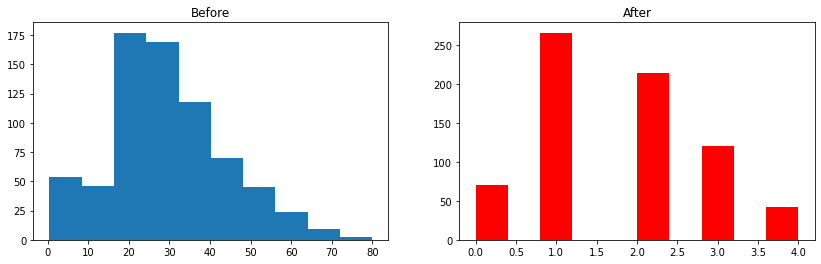

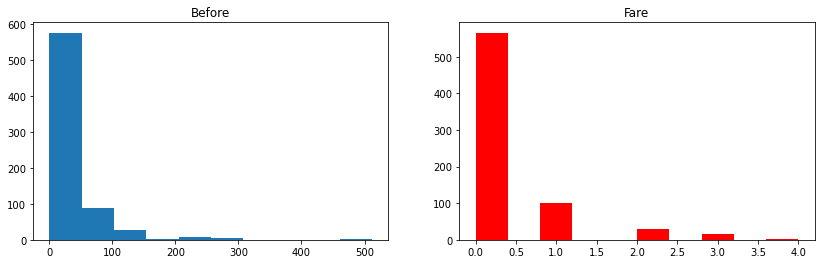

In [43]:
discretize(5,'kmeans')

<h5 style="color:#78B89A; font-weight:bold;">9. Custom / Domain-Based Binning</h5>

Sometimes the best bin boundaries come from **domain knowledge**, not from an automatic algorithm.

Example:

```text
Age

0–12    → Child
13–19   → Teen
20–59   → Adult
60+     → Senior
```

Or for income:

```text
< 30k       → Low
30k–80k     → Medium
80k–150k    → High
150k+       → Very High
```

In Python, `pd.cut()` is useful when you already know the boundaries:

```python
age_bins = [0, 12, 19, 59, 120]

age_labels = [
    "Child",
    "Teen",
    "Adult",
    "Senior"
]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels
)
```

### When is custom binning useful?

```text
Business rule
     ↓
Known meaningful thresholds
     ↓
Custom bins
```

Examples:
- age groups
- credit-risk bands
- income brackets
- medical ranges
- business-defined customer segments

Be careful: arbitrary bins can throw away useful information.

<h5 style="color:#78B89A; font-weight:bold;">10. Binarization</h5>

**Binarization = converting numerical values into 0 or 1 using a threshold.**

Basic rule:

```text
x > threshold → 1
x ≤ threshold → 0
```

Example:

```text
Age > 18 ?

Age = 25 → 1
Age = 15 → 0
```

Scikit-learn:

```python
from sklearn.preprocessing import Binarizer

Binarizer(threshold=18)
```

### Flow

```text
Numerical feature
       ↓
Compare with threshold
       ↓
 ┌─────┴─────┐
 ≤ threshold > threshold
      ↓            ↓
      0            1
```

Binarization is useful when the **presence/absence** or **above/below threshold** meaning is more useful than the exact numerical value.

<h5 style="color:#78B89A; font-weight:bold;">11. Binarization — Practical Example</h5>

Your second uploaded notebook uses the Titanic dataset and creates:

```text
family = SibSp + Parch
```

Then it compares:

```text
WITHOUT binarization
        ↓
Decision Tree
        ↓
accuracy

VS

WITH binarization
        ↓
family → 0 / 1
        ↓
Decision Tree
        ↓
accuracy
```

The source uses:

```python
Binarizer(copy=False)
```

inside a `ColumnTransformer`.

The complete source-based binarization notebook is included below.

In [28]:
import numpy as np
import pandas as pd

In [29]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score

from sklearn.compose import ColumnTransformer

In [30]:
df = pd.read_csv('train.csv')[['Age','Fare','SibSp','Parch','Survived']]

In [31]:
df.dropna(inplace=True)

In [32]:
df.head()

,Age,Fare,SibSp,Parch,Survived
0,22.0,7.2500,1,0,0
1,38.0,71.2833,1,0,1
2,26.0,7.9250,0,0,1
3,35.0,53.1000,1,0,1
4,35.0,8.0500,0,0,0


In [33]:
df['family'] = df['SibSp'] + df['Parch']

In [34]:
df.head()

,Age,Fare,SibSp,Parch,Survived,family
0,22.0,7.2500,1,0,0,1
1,38.0,71.2833,1,0,1,1
2,26.0,7.9250,0,0,1,0
3,35.0,53.1000,1,0,1,1
4,35.0,8.0500,0,0,0,0


In [35]:
df.drop(columns=['SibSp','Parch'],inplace=True)

In [36]:
df.head()

,Age,Fare,Survived,family
0,22.0,7.2500,0,1
1,38.0,71.2833,1,1
2,26.0,7.9250,1,0
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [37]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [38]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [39]:
X_train.head()

,Age,Fare,family
328,31.0,20.5250,2
73,26.0,14.4542,1
253,30.0,16.1000,1
719,33.0,7.7750,0
666,25.0,13.0000,0


In [40]:
# Without binarization

clf = DecisionTreeClassifier()

clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)

accuracy_score(y_test,y_pred)

0.6293706293706294

In [41]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

0.6429381846635367

In [20]:
# Applying Binarization

from sklearn.preprocessing import Binarizer

In [42]:
trf = ColumnTransformer([
    ('bin',Binarizer(copy=False),['family'])
],remainder='passthrough')

In [43]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [44]:
pd.DataFrame(X_train_trf,columns=['family','Age','Fare'])

,family,Age,Fare
0,1.0,31.0,20.5250
1,1.0,26.0,14.4542
2,1.0,30.0,16.1000
3,0.0,33.0,7.7750
4,0.0,25.0,13.0000
...,...,...,...
566,1.0,46.0,61.1750
567,0.0,25.0,13.0000
568,0.0,41.0,134.5000
569,1.0,33.0,20.5250


In [45]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

accuracy_score(y_test,y_pred2)

0.6363636363636364

In [46]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X_trf,y,cv=10,scoring='accuracy'))

0.6304186228482003

<h3 style="color:#6FA8DC; font-weight:bold">Modern ML Pattern — Binning + Pipeline</h3>

For a production-style workflow, put discretization inside the Pipeline so that bin boundaries are learned from **training data only**.

```text
Train data
   ↓
KBinsDiscretizer.fit()
   ↓
learn bin edges
   ↓
transform train
   ↓
Model
```

Then:

```text
Test / New data
   ↓
same fitted bin edges
   ↓
transform
   ↓
Model
```

This avoids learning bin boundaries from the test set.

Example:

```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.tree import DecisionTreeClassifier

pipe = Pipeline([
    ("binning", KBinsDiscretizer(
        n_bins=5,
        strategy="quantile",
        encode="ordinal"
    )),
    ("model", DecisionTreeClassifier(random_state=42))
])

pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
```

For different columns needing different preprocessing, combine `KBinsDiscretizer` with `ColumnTransformer`.

<h3 style="color:#6FA8DC; font-weight:bold">Final Revision</h3>

```text
NUMERICAL FEATURE
       │
       ├── Want ranges/groups?
       │       ↓
       │   DISCRETIZATION
       │       │
       │       ├── Uniform
       │       │   → equal width
       │       │
       │       ├── Quantile
       │       │   → roughly equal frequency
       │       │
       │       ├── KMeans
       │       │   → cluster-based
       │       │
       │       └── Custom
       │           → domain-based
       │
       └── Want only 0 / 1?
               ↓
           BINARIZATION
```

### One-line definitions

**Discretization:** convert a continuous numerical feature into discrete bins.

**Binarization:** convert a numerical feature into binary `0/1` values using a threshold.

### Most important comparison

| Method | Main idea |
|---|---|
| Uniform | Equal-width numerical intervals |
| Quantile | Approximately equal number of observations per bin |
| KMeans | Cluster-based boundaries |
| Custom | Domain/business-defined boundaries |
| Binarization | Threshold → `0` or `1` |

### Final rule

> **Binning and binarization are feature-engineering choices, not mandatory preprocessing steps. Always compare model performance and consider information loss.**